Using device: cpu
Train: torch.Size([3200, 2]) torch.Size([3200])
Val: torch.Size([800, 2]) torch.Size([800])

Running experiment for activation = sigmoid
[sigmoid] Epoch 001 | train_loss=0.7104 | val_loss=0.6954 | val_acc=0.4975
[sigmoid] Epoch 010 | train_loss=0.6949 | val_loss=0.6948 | val_acc=0.4975
[sigmoid] Epoch 020 | train_loss=0.6957 | val_loss=0.6932 | val_acc=0.4975
[sigmoid] Epoch 030 | train_loss=0.6936 | val_loss=0.6975 | val_acc=0.4975
[sigmoid] Epoch 040 | train_loss=0.6936 | val_loss=0.6946 | val_acc=0.5025
[sigmoid] Epoch 050 | train_loss=0.6934 | val_loss=0.6933 | val_acc=0.5025
[sigmoid] Epoch 060 | train_loss=0.6941 | val_loss=0.6932 | val_acc=0.4975
[sigmoid] Epoch 070 | train_loss=0.6936 | val_loss=0.6933 | val_acc=0.5025
[sigmoid] Epoch 080 | train_loss=0.6939 | val_loss=0.6936 | val_acc=0.4975

Running experiment for activation = tanh
[   tanh] Epoch 001 | train_loss=0.4864 | val_loss=0.1747 | val_acc=0.9337
[   tanh] Epoch 010 | train_loss=0.1898 | val_loss=0.

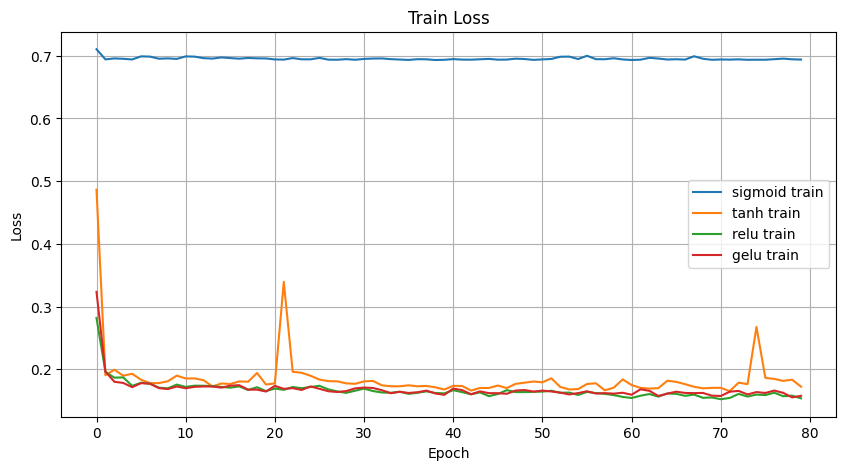

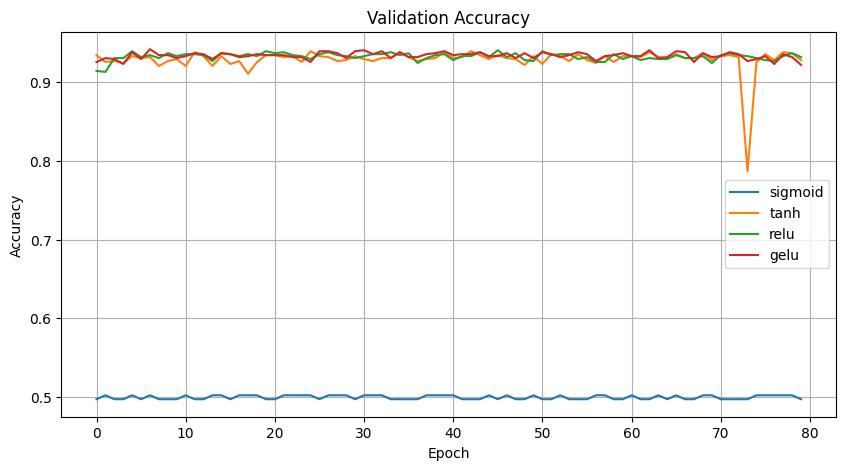

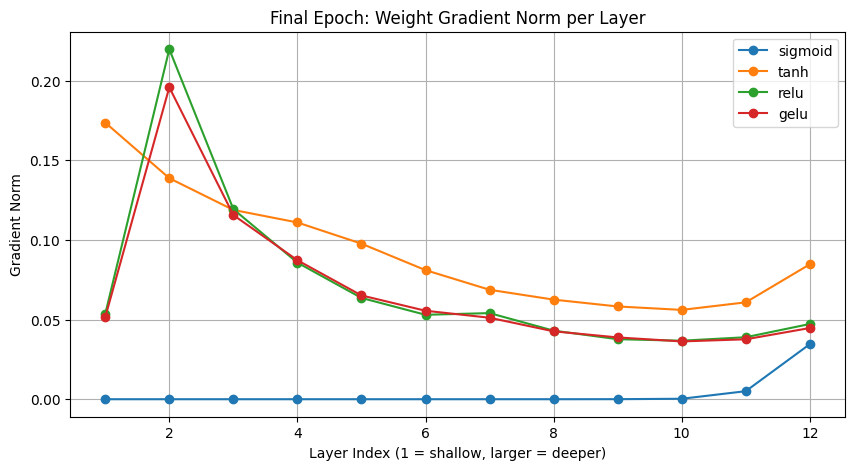

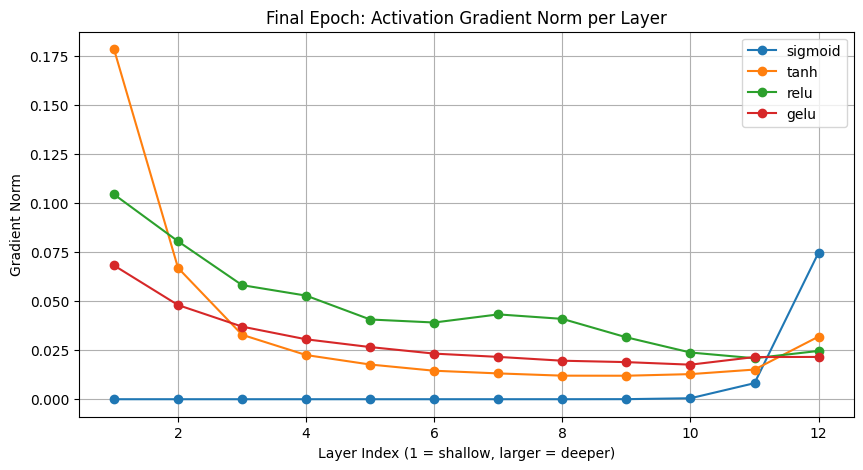

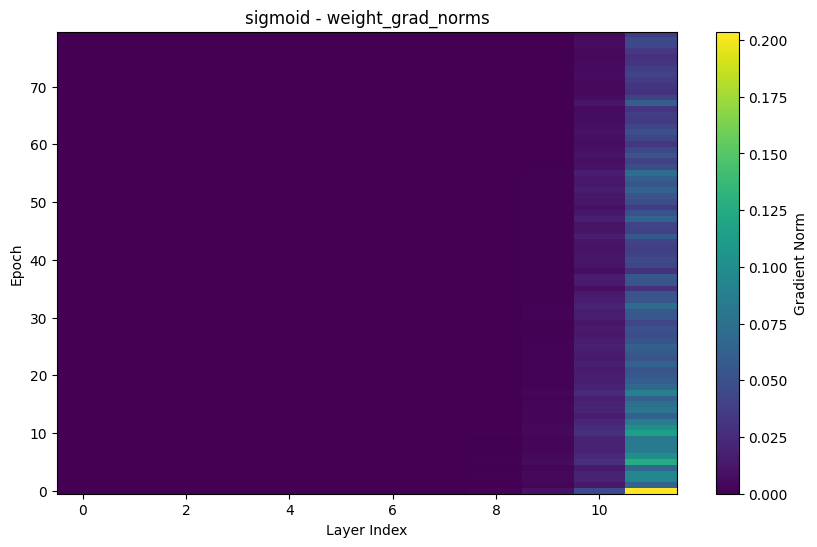

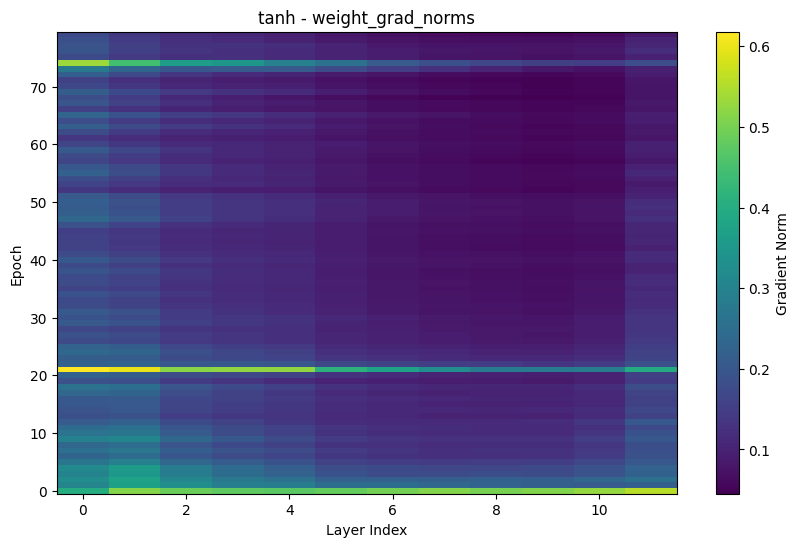

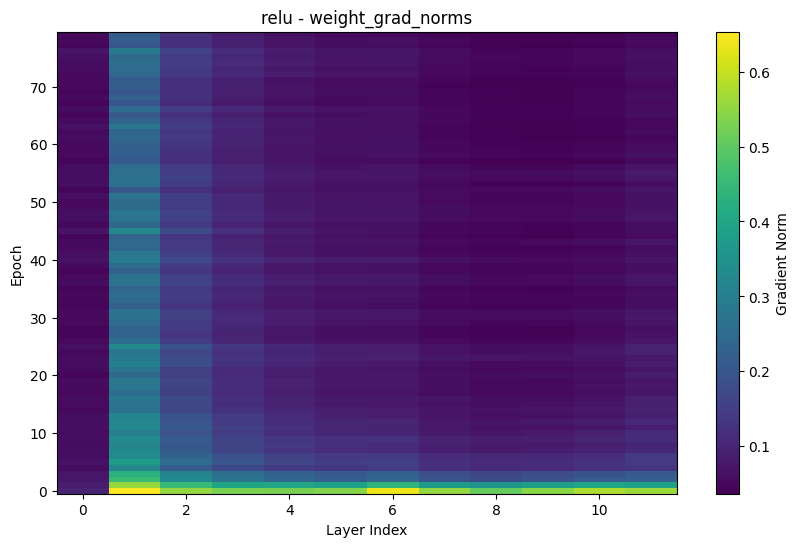

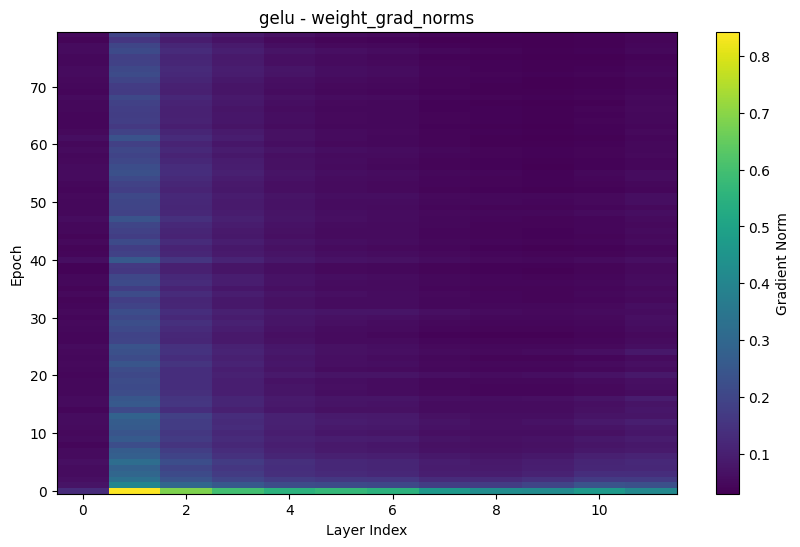

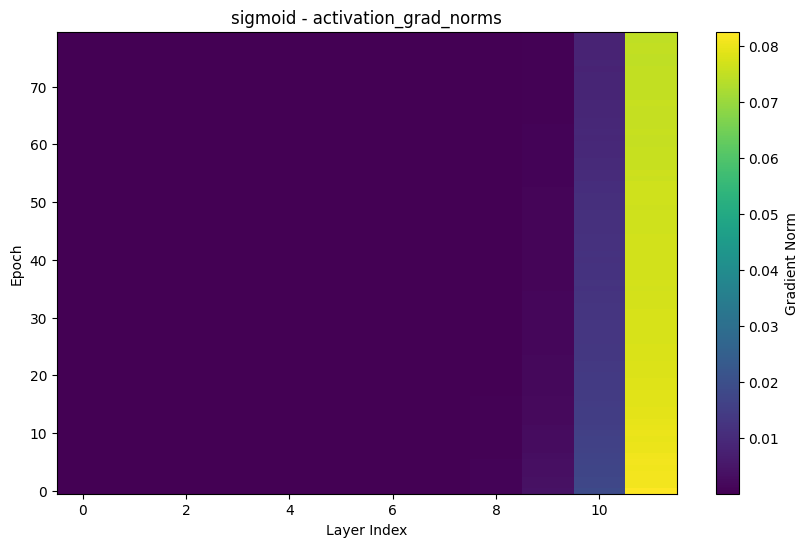

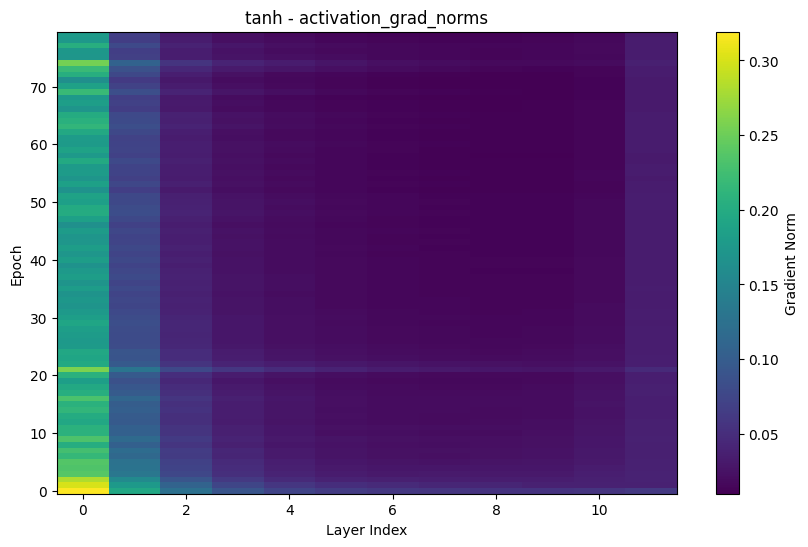

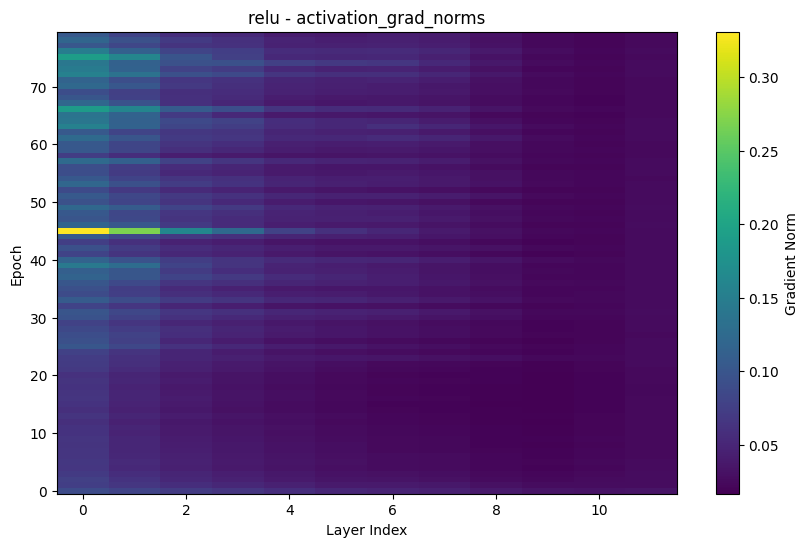

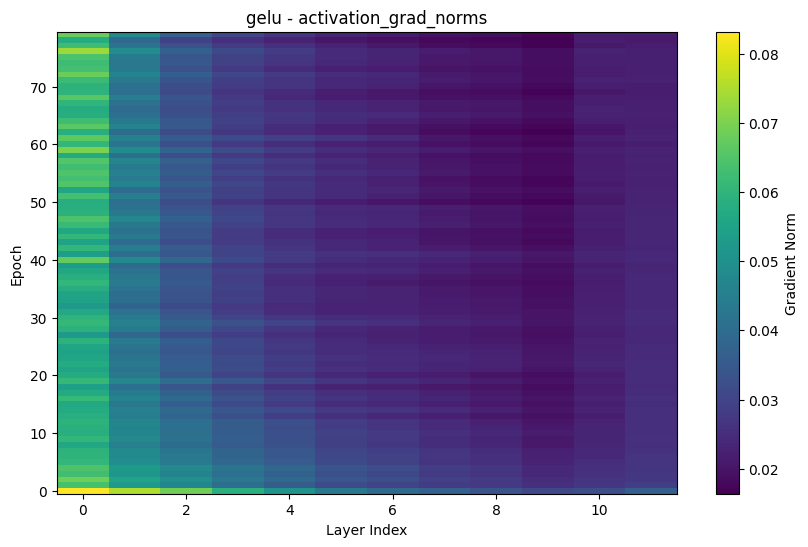

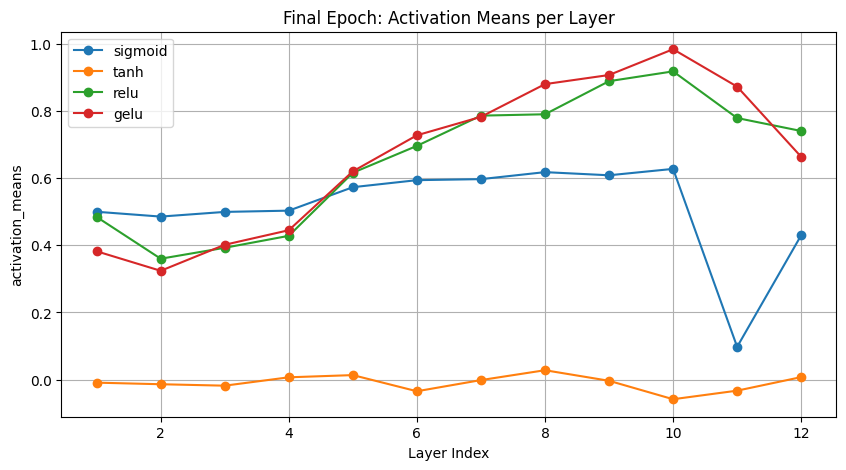

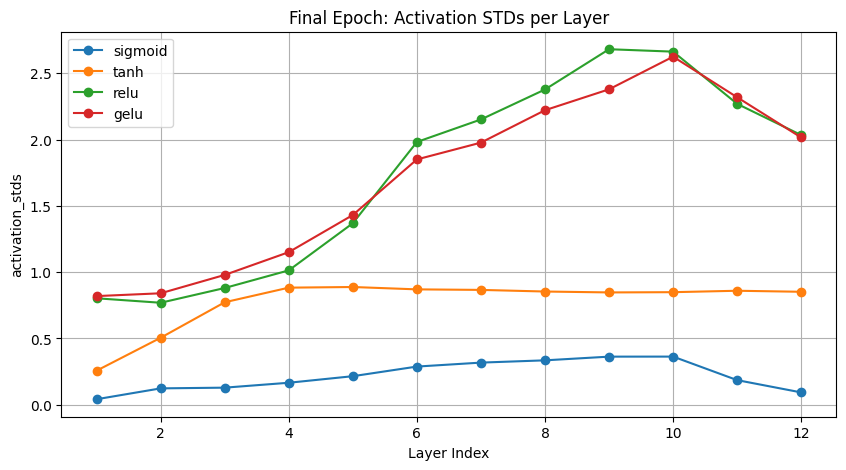

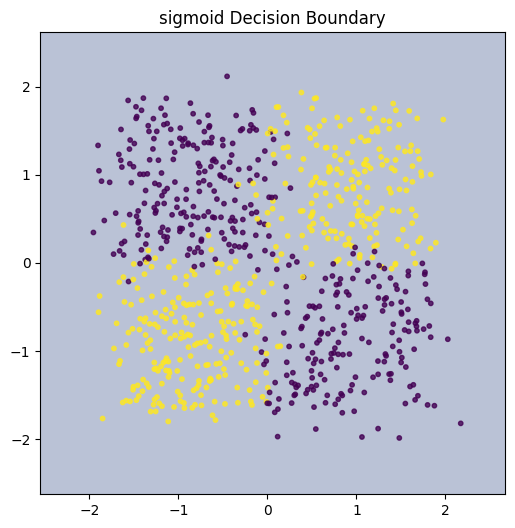

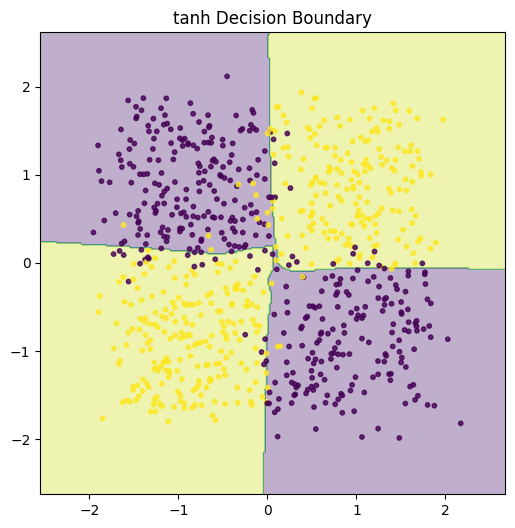

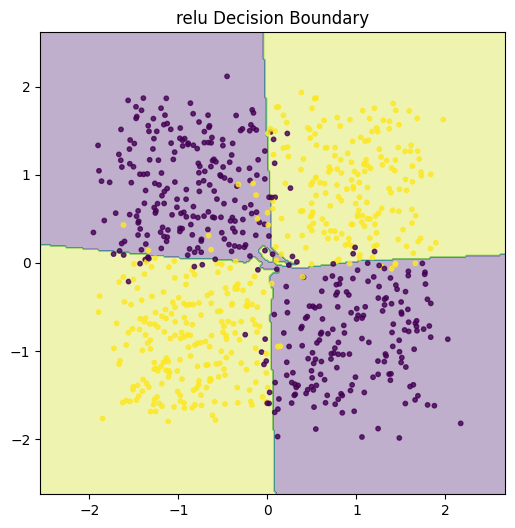

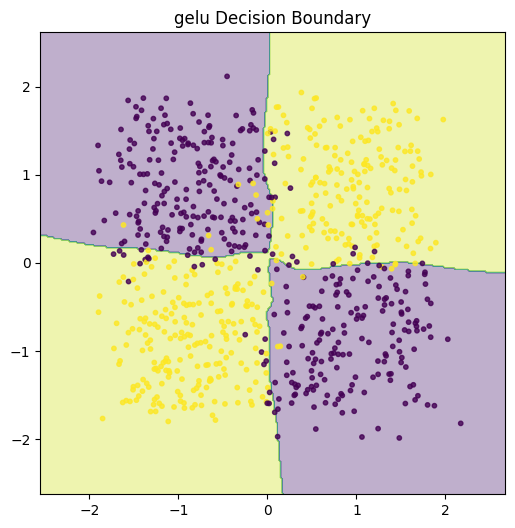

In [1]:
# =========================
# Colab / PyTorch 实验：
# 对比 sigmoid / tanh / relu / gelu 的梯度传播
# =========================

import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -------------------------
# 1. 固定随机种子
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# 2. 造一个非线性分类数据集
#    用二维输入，方便后续可视化
# -------------------------
def make_xor_dataset(n=4000, noise=0.15):
    x = np.random.uniform(-2.0, 2.0, size=(n, 2)).astype(np.float32)
    y = ((x[:, 0] * x[:, 1]) > 0).astype(np.int64)  # XOR-like: 同号为1，异号为0

    x += np.random.normal(0, noise, size=x.shape).astype(np.float32)

    # 标准化
    x = (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + 1e-6)
    return torch.tensor(x), torch.tensor(y)

X, y = make_xor_dataset(n=4000, noise=0.20)

# 划分 train / val
perm = torch.randperm(len(X))
train_idx = perm[:3200]
val_idx = perm[3200:]

X_train, y_train = X[train_idx].to(device), y[train_idx].to(device)
X_val, y_val = X[val_idx].to(device), y[val_idx].to(device)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

# -------------------------
# 3. 构建深层 MLP
# -------------------------
class DeepMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128, depth=12, out_dim=2, act_name="relu"):
        super().__init__()
        self.act_name = act_name

        layers = []
        dims = [in_dim] + [hidden_dim] * depth + [out_dim]

        self.linears = nn.ModuleList()
        self.activations = []

        for i in range(len(dims) - 2):
            self.linears.append(nn.Linear(dims[i], dims[i+1]))
        self.out = nn.Linear(dims[-2], dims[-1])

        self.act = self._get_activation(act_name)

        self._init_weights()

    def _get_activation(self, name):
        name = name.lower()
        if name == "sigmoid":
            return nn.Sigmoid()
        elif name == "tanh":
            return nn.Tanh()
        elif name == "relu":
            return nn.ReLU()
        elif name == "gelu":
            return nn.GELU()
        else:
            raise ValueError(f"Unsupported activation: {name}")

    def _init_weights(self):
        # 为了公平，对不同激活函数做相对合理的初始化
        for linear in self.linears:
            if self.act_name in ["relu", "gelu"]:
                nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            elif self.act_name == "tanh":
                nn.init.xavier_normal_(linear.weight, gain=nn.init.calculate_gain("tanh"))
            elif self.act_name == "sigmoid":
                nn.init.xavier_normal_(linear.weight, gain=1.0)
            nn.init.zeros_(linear.bias)

        if self.act_name in ["relu", "gelu"]:
            nn.init.kaiming_normal_(self.out.weight, nonlinearity="linear")
        else:
            nn.init.xavier_normal_(self.out.weight, gain=1.0)
        nn.init.zeros_(self.out.bias)

    def forward(self, x, save_for_stats=False):
        activation_tensors = []
        preact_tensors = []

        for linear in self.linears:
            x = linear(x)
            preact = x
            x = self.act(x)

            if save_for_stats:
                # 保存 activation，并保留梯度，便于观察反向传播到每层输出的梯度
                x.retain_grad()
                activation_tensors.append(x)
                preact_tensors.append(preact)

        logits = self.out(x)

        if save_for_stats:
            return logits, activation_tensors, preact_tensors
        return logits


# -------------------------
# 4. 训练与统计函数
# -------------------------
@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(X)
    loss = nn.CrossEntropyLoss()(logits, y).item()
    pred = logits.argmax(dim=1)
    acc = (pred == y).float().mean().item()
    return loss, acc


def run_experiment(
    act_name,
    epochs=80,
    batch_size=128,
    lr=1e-3,
    hidden_dim=128,
    depth=12
):
    model = DeepMLP(
        in_dim=2,
        hidden_dim=hidden_dim,
        depth=depth,
        out_dim=2,
        act_name=act_name
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    n_train = X_train.shape[0]

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        # 每个 epoch 记录每层平均梯度范数
        "weight_grad_norms": [],      # shape: [epoch][layer]
        "activation_grad_norms": [],  # shape: [epoch][layer]
        "activation_means": [],       # shape: [epoch][layer]
        "activation_stds": [],        # shape: [epoch][layer]
    }

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n_train, device=device)

        epoch_loss = 0.0
        batch_count = 0

        # 用于统计本 epoch 每层平均值
        num_layers = depth
        weight_grad_sum = torch.zeros(num_layers, device=device)
        activation_grad_sum = torch.zeros(num_layers, device=device)
        activation_mean_sum = torch.zeros(num_layers, device=device)
        activation_std_sum = torch.zeros(num_layers, device=device)
        stat_count = 0

        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            xb = X_train[idx]
            yb = y_train[idx]

            optimizer.zero_grad()

            logits, activations, _ = model(xb, save_for_stats=True)
            loss = criterion(logits, yb)
            loss.backward()

            # 统计每层：
            # 1) 线性层权重梯度范数
            # 2) 激活输出张量的梯度范数
            # 3) 激活输出均值、标准差
            for layer_idx, linear in enumerate(model.linears):
                if linear.weight.grad is not None:
                    weight_grad_sum[layer_idx] += linear.weight.grad.norm().detach()

            for layer_idx, act_tensor in enumerate(activations):
                if act_tensor.grad is not None:
                    activation_grad_sum[layer_idx] += act_tensor.grad.norm().detach()
                activation_mean_sum[layer_idx] += act_tensor.detach().mean()
                activation_std_sum[layer_idx] += act_tensor.detach().std()

            stat_count += 1

            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        # 记录 epoch 平均统计
        history["train_loss"].append(epoch_loss / batch_count)
        history["weight_grad_norms"].append((weight_grad_sum / stat_count).cpu().numpy())
        history["activation_grad_norms"].append((activation_grad_sum / stat_count).cpu().numpy())
        history["activation_means"].append((activation_mean_sum / stat_count).cpu().numpy())
        history["activation_stds"].append((activation_std_sum / stat_count).cpu().numpy())

        val_loss, val_acc = evaluate(model, X_val, y_val)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"[{act_name:>7}] "
                f"Epoch {epoch+1:03d} | "
                f"train_loss={history['train_loss'][-1]:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

    return model, history


# -------------------------
# 5. 运行四组实验
# -------------------------
activations = ["sigmoid", "tanh", "relu", "gelu"]
results = {}

for act in activations:
    print("\n" + "=" * 80)
    print(f"Running experiment for activation = {act}")
    print("=" * 80)
    set_seed(42)  # 保证各实验尽量公平
    model, history = run_experiment(
        act_name=act,
        epochs=80,
        batch_size=128,
        lr=1e-3,
        hidden_dim=128,
        depth=12
    )
    results[act] = {
        "model": model,
        "history": history
    }


# -------------------------
# 6. 可视化：训练 loss / 验证准确率
# -------------------------
def plot_training_curves(results):
    plt.figure(figsize=(10, 5))
    for act, payload in results.items():
        h = payload["history"]
        plt.plot(h["train_loss"], label=f"{act} train")
    plt.title("Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    for act, payload in results.items():
        h = payload["history"]
        plt.plot(h["val_acc"], label=f"{act}")
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_curves(results)


# -------------------------
# 7. 可视化：最后一个 epoch 的每层权重梯度范数
# -------------------------
def plot_final_layer_gradients(results, key="weight_grad_norms", title="Final Epoch Layer Gradient Norms"):
    plt.figure(figsize=(10, 5))
    for act, payload in results.items():
        h = payload["history"]
        vals = h[key][-1]  # 最后一个 epoch
        layers = np.arange(1, len(vals) + 1)
        plt.plot(layers, vals, marker='o', label=act)

    plt.title(title)
    plt.xlabel("Layer Index (1 = shallow, larger = deeper)")
    plt.ylabel("Gradient Norm")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_final_layer_gradients(
    results,
    key="weight_grad_norms",
    title="Final Epoch: Weight Gradient Norm per Layer"
)

plot_final_layer_gradients(
    results,
    key="activation_grad_norms",
    title="Final Epoch: Activation Gradient Norm per Layer"
)


# -------------------------
# 8. 可视化：梯度传播热力图
#    横轴=层，纵轴=epoch，颜色=梯度范数
# -------------------------
def plot_gradient_heatmap(results, act_name, key="weight_grad_norms"):
    arr = np.array(results[act_name]["history"][key])  # [epochs, layers]

    plt.figure(figsize=(10, 6))
    plt.imshow(arr, aspect='auto', origin='lower')
    plt.colorbar(label="Gradient Norm")
    plt.title(f"{act_name} - {key}")
    plt.xlabel("Layer Index")
    plt.ylabel("Epoch")
    plt.show()

for act in activations:
    plot_gradient_heatmap(results, act, key="weight_grad_norms")

for act in activations:
    plot_gradient_heatmap(results, act, key="activation_grad_norms")


# -------------------------
# 9. 可视化：最后一个 epoch 的激活统计
# -------------------------
def plot_final_activation_stats(results, key="activation_means", title="Final Epoch Activation Means"):
    plt.figure(figsize=(10, 5))
    for act, payload in results.items():
        vals = payload["history"][key][-1]
        layers = np.arange(1, len(vals) + 1)
        plt.plot(layers, vals, marker='o', label=act)

    plt.title(title)
    plt.xlabel("Layer Index")
    plt.ylabel(key)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_final_activation_stats(results, key="activation_means", title="Final Epoch: Activation Means per Layer")
plot_final_activation_stats(results, key="activation_stds", title="Final Epoch: Activation STDs per Layer")


# -------------------------
# 10. 额外：看某个激活函数的决策边界
# -------------------------
@torch.no_grad()
def plot_decision_boundary(model, title="Decision Boundary"):
    model.eval()

    x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
    y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_t = torch.tensor(grid, device=device)

    logits = model(grid_t)
    pred = logits.argmax(dim=1).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, pred, alpha=0.35)
    plt.scatter(
        X_val[:, 0].cpu().numpy(),
        X_val[:, 1].cpu().numpy(),
        c=y_val.cpu().numpy(),
        s=10,
        alpha=0.8
    )
    plt.title(title)
    plt.show()

for act in activations:
    plot_decision_boundary(results[act]["model"], title=f"{act} Decision Boundary")